In [9]:
import pandas as pd
import numpy as np
import ta
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.model_selection import GridSearchCV

2. Load Dataset

In [10]:
df = pd.read_csv(r"C:\Users\mouni\Downloads\all_stocks_5yr.csv\all_stocks_5yr.csv")

df['date'] = pd.to_datetime(df['date'])

# Select one stock (AAPL)
df = df[df['Name'] == 'AAPL'].copy()
df = df.sort_values(by='date')
df.reset_index(drop=True, inplace=True)

3.  Feature Engineering

In [11]:
df['RSI'] = ta.momentum.RSIIndicator(df['close'], window=14).rsi()

# MACD
macd = ta.trend.MACD(df['close'])
df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()
df['MACD_diff'] = macd.macd_diff()

# Bollinger Bands
bb = ta.volatility.BollingerBands(df['close'])
df['BB_high'] = bb.bollinger_hband()
df['BB_low'] = bb.bollinger_lband()
df['BB_mid'] = bb.bollinger_mavg()

# Moving Averages
df['MA5'] = df['close'].rolling(5).mean()
df['MA20'] = df['close'].rolling(20).mean()

4. Target Variable

In [12]:
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

# Drop NaNs
df = df.dropna()

5. Features & Split

In [13]:
features = [
    'RSI', 'MACD', 'MACD_signal', 'MACD_diff',
    'BB_high', 'BB_low', 'BB_mid',
    'MA5', 'MA20', 'volume'
]

X = df[features]
y = df['target']

# Time-based split (80-20)
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

6. Scaling

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

7. Linear SVM

In [22]:
linear_svm = SVC(kernel='linear', probability=True)
linear_svm.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


8. RBF SVM (with tuning)

In [16]:
params = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1]
}

rbf_model = GridSearchCV(SVC(kernel='rbf', probability=True), params, cv=3)
rbf_model.fit(X_train, y_train)

rbf_svm = rbf_model.best_estimator_

print("Best RBF Params:", rbf_model.best_params_)


Best RBF Params: {'C': 10, 'gamma': 0.01}


9. Predictions

In [18]:
y_pred_lin = linear_svm.predict(X_test)
y_pred_rbf = rbf_svm.predict(X_test)

y_prob_lin = linear_svm.predict_proba(X_test)[:, 1]
y_prob_rbf = rbf_svm.predict_proba(X_test)[:, 1]

10. Evaluation Function

In [19]:
def evaluate(y_true, y_pred, y_prob, name):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("AUC-ROC:", roc_auc_score(y_true, y_prob))

# Evaluate both models
evaluate(y_test, y_pred_lin, y_prob_lin, "Linear SVM")
evaluate(y_test, y_pred_rbf, y_prob_rbf, "RBF SVM")


Linear SVM Results:
Accuracy: 0.5203252032520326
Precision: 0.5203252032520326
Recall: 1.0
AUC-ROC: 0.4369041313559322

RBF SVM Results:
Accuracy: 0.5
Precision: 0.8571428571428571
Recall: 0.046875
AUC-ROC: 0.5256554555084747


11. Confusion Matrix Plot

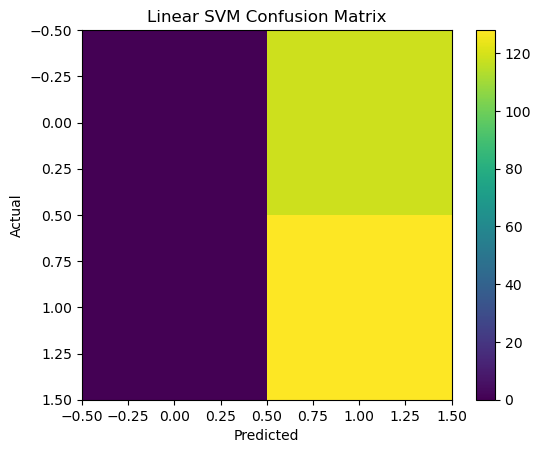

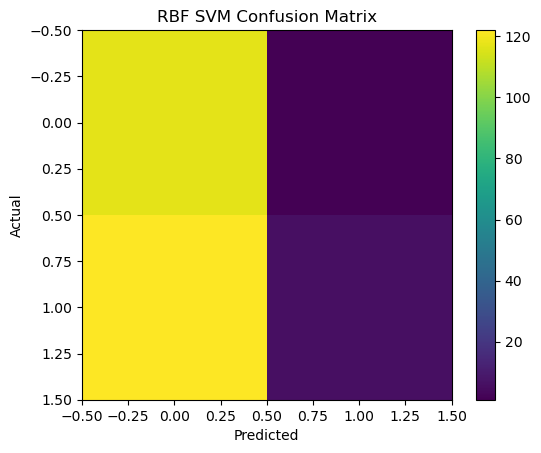

In [20]:
def plot_confusion(cm, title):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

cm_lin = confusion_matrix(y_test, y_pred_lin)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plot_confusion(cm_lin, "Linear SVM Confusion Matrix")
plot_confusion(cm_rbf, "RBF SVM Confusion Matrix")


12. ROC Curve

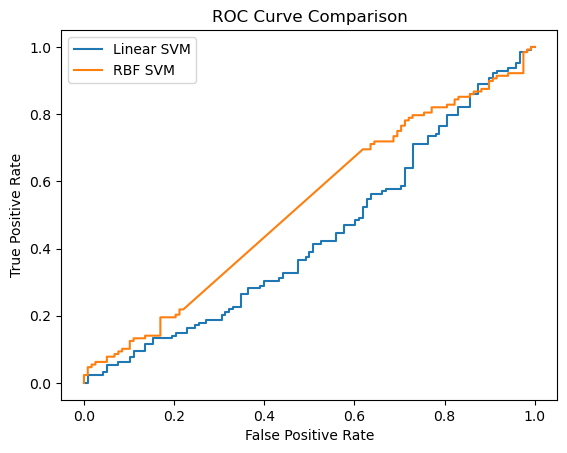

In [21]:
fpr_lin, tpr_lin, _ = roc_curve(y_test, y_prob_lin)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_rbf)

plt.figure()
plt.plot(fpr_lin, tpr_lin, label="Linear SVM")
plt.plot(fpr_rbf, tpr_rbf, label="RBF SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()